<a href="https://colab.research.google.com/github/Akshaya24555/CodSoft/blob/main/exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>EXPERIMENT 8</center>

<center>TIME SERIES ANALYSIS FOR WEATHER PREDICTION USING LSTM</center>



**AIM:**

To build and train a Long Short-Term Memory (LSTM) neural network to perform time series forecasting on weather data (temperature), and
predict future values based on past trends.

**PRE-REQUISITES:**

1. Basics of Machine Learning
2. Python Programming
3. Knowledge on Numpy, Pandas, Matplotlib, TensorFlow/ Keras
4. Jupyter Notebook
5. Data Pre-Processing Techniques
6. Knowledge on Neural Networks

**1. Importing the Basic Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load the Dataset**

In [ ]:
df = pd.read_csv('/content/weatherdataset-6.csv')
df.head()

,Date,Temperature (C)
0,2000-01-01 00:00:00,19.607124
1,2000-01-01 01:00:00,16.187752
2,2000-01-01 02:00:00,21.111840
3,2000-01-01 03:00:00,18.599300
4,2000-01-01 04:00:00,18.527740


In [ ]:
df.tail()

,Date,Temperature (C)
29995,2003-06-03 19:00:00,15.686443
29996,2003-06-03 20:00:00,23.592292
29997,2003-06-03 21:00:00,22.792064
29998,2003-06-03 22:00:00,20.574201
29999,2003-06-03 23:00:00,20.058540


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             30000 non-null  object 
 1   Temperature (C)  30000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 468.9+ KB


**3. Pre-Process the Dataset**

a) Handle any Null Values

In [ ]:
df.isnull().sum()


,0
Date,0
Temperature (C),0


b) Standardize the Date Column

In [ ]:
df.head(2)
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values('Date')

In [ ]:
df.head()

,Date,Temperature (C)
0,2000-01-01 00:00:00+00:00,19.607124
1,2000-01-01 01:00:00+00:00,16.187752
2,2000-01-01 02:00:00+00:00,21.111840
3,2000-01-01 03:00:00+00:00,18.599300
4,2000-01-01 04:00:00+00:00,18.527740


c) Set the Traget Variable & Scale the Values

In [ ]:
temperature = df[['Temperature (C)']]
temperature

,Temperature (C)
0,19.607124
1,16.187752
2,21.111840
3,18.599300
4,18.527740
...,...
29995,15.686443
29996,23.592292
29997,22.792064
29998,20.574201


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
temperature = scaler.fit_transform(temperature)
temperature

array([[0.47498886],
       [0.37326987],
       [0.51975091],
       ...,
       [0.56973397],
       [0.5037573 ],
       [0.48841751]])

4. Create Data Sequences



*   LSTM models donʼt just take independent data points, they learn patterns over time. So instead of giving just a single temperature value
as input, we give the model a sequence of past values (e.g., past 60 hours of temperature). Then the model tries to predict the next
value (temperature at the 61st hour). This process is called sliding window approach for time series forecasting.

In [ ]:
def create_sequences(dataset, time_step=72):
    X, y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

In [ ]:
time_step = 72
X, y = create_sequences(temperature, time_step)

In [ ]:
X[0], y[0]


(array([0.47498886, 0.37326987, 0.51975091, 0.44500826, 0.44287948,
        0.48863268, 0.42511809, 0.52921275, 0.47465716, 0.46481662,
        0.4290369 , 0.54355634, 0.39971383, 0.52815927, 0.59266406,
        0.48647652, 0.5535345 , 0.36014222, 0.62430486, 0.48502937,
        0.50713116, 0.59118432, 0.72576617, 0.51510233, 0.55347724,
        0.51163159, 0.53910175, 0.5973876 , 0.55632075, 0.51309665,
        0.44556421, 0.57685294, 0.50054816, 0.57828006, 0.54439628,
        0.41478642, 0.50168714, 0.43370139, 0.6767822 , 0.57616123,
        0.53213351, 0.5888435 , 0.53732174, 0.58064648, 0.66268346,
        0.54776672, 0.59634274, 0.53888687, 0.73281976, 0.5934331 ,
        0.5555968 , 0.44710803, 0.45814421, 0.53734546, 0.57833552,
        0.60982967, 0.64560709, 0.54524235, 0.53975692, 0.53156096,
        0.53010617, 0.54164043, 0.59193322, 0.55055696, 0.62083163,
        0.5370252 , 0.43136607, 0.56015235, 0.57570344, 0.55488247,
        0.54300227, 0.58588623]),
 np.float64(0.

**4. Split the Data into Train & Test Data**

In [ ]:
train_size = int(len(X) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
X_train[1]

array([0.37326987, 0.51975091, 0.44500826, 0.44287948, 0.48863268,
       0.42511809, 0.52921275, 0.47465716, 0.46481662, 0.4290369 ,
       0.54355634, 0.39971383, 0.52815927, 0.59266406, 0.48647652,
       0.5535345 , 0.36014222, 0.62430486, 0.48502937, 0.50713116,
       0.59118432, 0.72576617, 0.51510233, 0.55347724, 0.51163159,
       0.53910175, 0.5973876 , 0.55632075, 0.51309665, 0.44556421,
       0.57685294, 0.50054816, 0.57828006, 0.54439628, 0.41478642,
       0.50168714, 0.43370139, 0.6767822 , 0.57616123, 0.53213351,
       0.5888435 , 0.53732174, 0.58064648, 0.66268346, 0.54776672,
       0.59634274, 0.53888687, 0.73281976, 0.5934331 , 0.5555968 ,
       0.44710803, 0.45814421, 0.53734546, 0.57833552, 0.60982967,
       0.64560709, 0.54524235, 0.53975692, 0.53156096, 0.53010617,
       0.54164043, 0.59193322, 0.55055696, 0.62083163, 0.5370252 ,
       0.43136607, 0.56015235, 0.57570344, 0.55488247, 0.54300227,
       0.58588623, 0.57636746])

In [ ]:
X_train.shape, X_test.shape

((20948, 72), (8979, 72))

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

5. Build LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_absolute_error')

**6. Train the Model**

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=10, batch_size=54, verbose=1)

Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - loss: 0.0806 - val_loss: 0.0565
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - loss: 0.0504 - val_loss: 0.0493
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - loss: 0.0513 - val_loss: 0.0501
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - loss: 0.0509 - val_loss: 0.0498
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - loss: 0.0499 - val_loss: 0.0499
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - loss: 0.0500 - val_loss: 0.0493
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - loss: 0.0500 - val_loss: 0.0514
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - loss: 0.0504 - val_loss: 0.0529
Epoch 9/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 44s 75ms/step - loss: 0.0495 - val_loss: 0.0490
Epoch 10/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - loss: 0.0500 - val_loss: 0.0534


**7. Evaluate the Predictions**

In [ ]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

655/655 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


In [ ]:
train_predict = scaler.inverse_transform(train_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
test_predict = scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

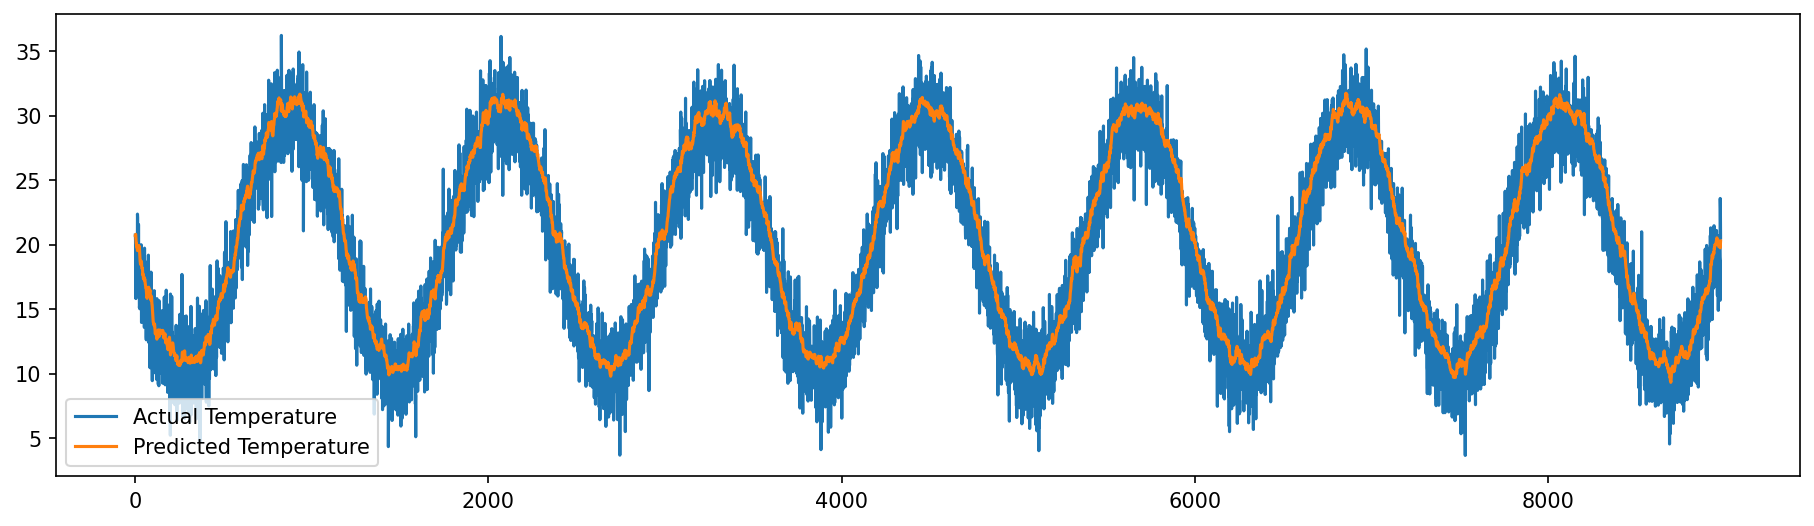

In [ ]:
plt.figure(figsize=(15,4), dpi=150)
plt.plot(y_test_actual, label="Actual Temperature")
plt.plot(test_predict, label="Predicted Temperature")
plt.legend()
plt.show()

**8. Forecast Future Temperature**

In [ ]:
last_sequence = temperature[-time_step:]
last_sequence = last_sequence.reshape(1, time_step, 1)
next_temp_scaled = model.predict(last_sequence)
next_temp = scaler.inverse_transform(next_temp_scaled)
print("Predicted next temperature:", next_temp[0][0], "°C")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted next temperature: 20.532036 °C


**RESULT:**

The Long Short-Term Memory (LSTM) neural network was successfully built and trained on the historical hourly temperature dataset.